<a href="https://colab.research.google.com/github/selvaganapathy18/Fdva/blob/main/fdva_exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            30 non-null     object 
 1   Gender             30 non-null     object 
 2   Married            29 non-null     object 
 3   Dependents         30 non-null     object 
 4   Education          29 non-null     object 
 5   Self_Employed      30 non-null     object 
 6   ApplicantIncome    29 non-null     float64
 7   CoapplicantIncome  30 non-null     int64  
 8   LoanAmount         30 non-null     int64  
 9   Loan_Amount_Term   30 non-null     int64  
 10  Credit_History     29 non-null     float64
 11  Property_Area      29 non-null     object 
dtypes: float64(2), int64(3), object(7)
memory usage: 2.9+ KB
None

Missing Values in Each Column:

Loan_ID              0
Gender               0
Married              1
Dependents           0
Education 

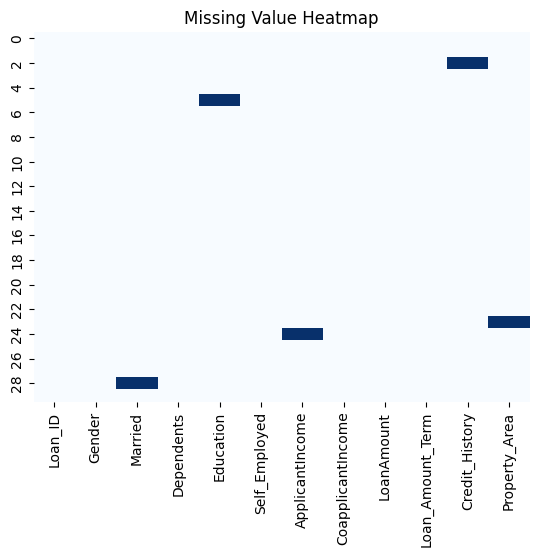


Removed 0 duplicate rows.

Cleaned Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            30 non-null     object 
 1   Gender             30 non-null     object 
 2   Married            30 non-null     object 
 3   Dependents         30 non-null     int64  
 4   Education          29 non-null     object 
 5   Self_Employed      30 non-null     object 
 6   ApplicantIncome    29 non-null     float64
 7   CoapplicantIncome  30 non-null     float64
 8   LoanAmount         30 non-null     float64
 9   Loan_Amount_Term   30 non-null     int64  
 10  Credit_History     30 non-null     float64
 11  Property_Area      29 non-null     object 
dtypes: float64(4), int64(2), object(6)
memory usage: 2.9+ KB
None
  Loan_ID  Gender Married  Dependents Education Self_Employed  \
0   LP001    Male     Yes           0  Grad

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv('loan.csv')

print("Initial Data Overview:")
print(df.info())

print("\nMissing Values in Each Column:\n")
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"\nRemoved {initial_rows - df.shape[0]} duplicate rows.")

df['Dependents'] = (
    df['Dependents']
    .replace('3+', 3)
    .fillna(0)
    .astype(int)
)

for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']:
    df[col] = df[col].str.strip().str.capitalize()

min_max_scaler = MinMaxScaler()
scale_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
df[scale_cols] = min_max_scaler.fit_transform(df[scale_cols])

scaler = StandardScaler()
df[['Credit_History']] = scaler.fit_transform(df[['Credit_History']])

print("\nCleaned Data Summary:")
print(df.info())
print(df.head())